# Creative Writing — 2. Cost Analysis

## Setup

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR   = Path("../dataset/results")
LOGS_DIR      = Path("../logs")
BASELINE_FILE = "claude_sonnet_4.6_result.csv"

GPU_RATE_LOW  = 2.0   # $/hr (H100)
GPU_RATE_HIGH = 3.5
CLAUDE_PRICE_INPUT  = 3.0   # $/1M input tokens
CLAUDE_PRICE_OUTPUT = 15.0  # $/1M output tokens

SCORE_MIN, SCORE_MAX = 0, 20

POSITIVE_CATEGORIES = [
    "Adherence to Instructions", "Believable Character Actions", "Nuanced Characters",
    "Consistent Voice / Tone of Writing", "Imagery and Descriptive Quality", "Elegant Prose",
    "Emotionally Engaging", "Emotionally Complex", "Coherent",
    "Well-earned Lightness or Darkness", "Sentences Flow Naturally",
    "Overall Reader Engagement", "Overall Impression",
]
NEGATIVE_CATEGORIES = [
    "Meandering", "Weak Dialogue", "Tell-Don't-Show", "Unsurprising or Uncreative",
    "Amateurish", "Purple Prose", "Overwrought",
    "Incongruent Ending Positivity", "Unearned Transformations",
]
ALL_CATEGORIES = POSITIVE_CATEGORIES + NEGATIVE_CATEGORIES
POS_COLS = [f"{c}_score" for c in POSITIVE_CATEGORIES]
NEG_COLS = [f"{c}_score" for c in NEGATIVE_CATEGORIES]
ALL_COLS = POS_COLS + NEG_COLS

def pretty_model(stem: str) -> str:
    return stem.replace("_result", "")

## Cost analysis

Computes throughput (tok/s) and effective cost per 1M tokens from inference logs.

$$\text{Throughput} = \frac{\sum \text{total\_tokens}}{\sum \text{latency\_s}} \qquad \text{Cost}_{1\text{M}} = \frac{10^6}{\text{Throughput} \times 3600} \times \text{Rate}_{\text{GPU}}$$

In [2]:
def parse_log(path: Path) -> dict:
    tot_tok = lat = prompt = completion = n_ok = n_total = 0
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            n_total += 1
            if e.get("status") == "ok":
                tot_tok    += e["total_tokens"]
                lat        += e["latency_ms"] / 1000
                prompt     += e["prompt_tokens"]
                completion += e["completion_tokens"]
                n_ok += 1
    return dict(n_ok=n_ok, n_total=n_total,
                total_tokens=tot_tok, latency_s=lat,
                prompt_tokens=prompt, completion_tokens=completion)

# Claude baseline
claude_raw = parse_log(LOGS_DIR / "llm_calls_claude-sonnet-4-6.jsonl")
claude_cost_total = (
    claude_raw["prompt_tokens"]     * CLAUDE_PRICE_INPUT  / 1_000_000
    + claude_raw["completion_tokens"] * CLAUDE_PRICE_OUTPUT / 1_000_000
)
CLAUDE_BLENDED = claude_cost_total / claude_raw["total_tokens"] * 1_000_000

print(f"Claude Sonnet 4.6  |  {claude_raw['n_ok']:,} requests  "
      f"|  blended ${CLAUDE_BLENDED:.2f}/1M tokens")

# Open-source models
cost_rows = []
for log_file in sorted(LOGS_DIR.glob("*.jsonl")):
    if "claude" in log_file.name:
        continue
    raw = parse_log(log_file)
    if raw["latency_s"] == 0:
        continue
    tput      = raw["total_tokens"] / raw["latency_s"]
    cost_low  = (1_000_000 / (tput * 3600)) * GPU_RATE_LOW
    cost_high = (1_000_000 / (tput * 3600)) * GPU_RATE_HIGH
    name = log_file.stem.replace("llm_calls_", "")
    cost_rows.append(dict(
        model=pretty_model(name),
        n_ok=raw["n_ok"],
        throughput=tput,
        cost_low=cost_low,
        cost_high=cost_high,
        cost_mid=(cost_low + cost_high) / 2,
        reduction_low=CLAUDE_BLENDED / cost_low,
        reduction_high=CLAUDE_BLENDED / cost_high,
    ))

cost_df = pd.DataFrame(cost_rows).sort_values("cost_low").reset_index(drop=True)

disp = cost_df[["model","n_ok","throughput","cost_low","cost_high","reduction_low","reduction_high"]].copy()
disp.columns = ["Model","N (ok)","Throughput (tok/s)","Cost/1M low","Cost/1M high","Reduction low","Reduction high"]
disp["Throughput (tok/s)"] = disp["Throughput (tok/s)"].map("{:.0f}".format)
disp["Cost/1M low"]  = disp["Cost/1M low"].map("${:.3f}".format)
disp["Cost/1M high"] = disp["Cost/1M high"].map("${:.3f}".format)
disp["Reduction low"]  = disp["Reduction low"].map("{:.1f}x".format)
disp["Reduction high"] = disp["Reduction high"].map("{:.1f}x".format)
display(disp)

Claude Sonnet 4.6  |  767 requests  |  blended $4.28/1M tokens


,Model,N (ok),Throughput (tok/s),Cost/1M low,Cost/1M high,Reduction low,Reduction high
0,Llama-3.2-3B-Instruct,811,2086,$0.266,$0.466,16.1x,9.2x
1,NVIDIA-Nemotron-3-Nano-4B-BF16,767,1706,$0.326,$0.570,13.1x,7.5x
2,gemma-4-E2B-it,767,1525,$0.364,$0.638,11.7x,6.7x
3,Qwen3.5-4B,767,1262,$0.440,$0.770,9.7x,5.6x
4,Qwen3-4B-Instruct-2507,767,1250,$0.444,$0.778,9.6x,5.5x
5,gemma-4-E4B-it,767,1012,$0.549,$0.960,7.8x,4.5x


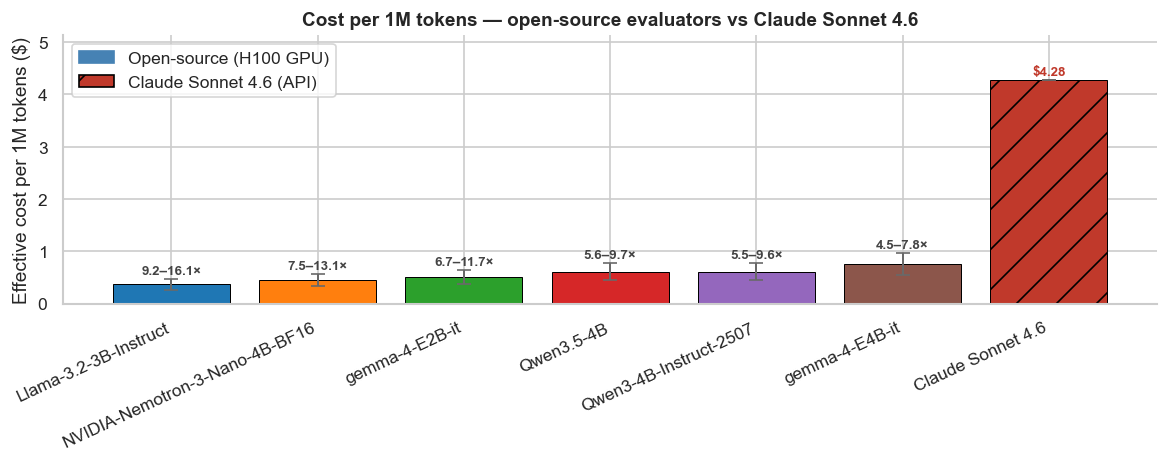

In [3]:
# Bar chart: cost per 1M tokens
fig, ax = plt.subplots(figsize=(10, 4))

labels = cost_df["model"].tolist() + ["Claude Sonnet 4.6"]
mids   = cost_df["cost_mid"].tolist() + [CLAUDE_BLENDED]
errs   = ((cost_df["cost_high"] - cost_df["cost_low"]) / 2).tolist() + [0]
colors = list(sns.color_palette("tab10", n_colors=len(cost_df))) + ["#c0392b"]

x = np.arange(len(labels))
bars = ax.bar(x, mids, yerr=errs, capsize=4, color=colors,
              edgecolor="black", linewidth=0.6,
              error_kw=dict(elinewidth=1.2, ecolor="dimgrey"),
              hatch=[""] * len(cost_df) + ["/"])

for bar, mid, err, rl, rh in zip(
        bars, cost_df["cost_mid"], (cost_df["cost_high"]-cost_df["cost_low"])/2,
        cost_df["reduction_low"], cost_df["reduction_high"]):
    ax.text(bar.get_x() + bar.get_width()/2, mid + err + 0.04,
            f"{rh:.1f}–{rl:.1f}×", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#444")

ax.text(bars[-1].get_x() + bars[-1].get_width()/2, CLAUDE_BLENDED + 0.04,
        f"${CLAUDE_BLENDED:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#c0392b")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Effective cost per 1M tokens ($)")
ax.set_ylim(0, CLAUDE_BLENDED * 1.2)
ax.set_title("Cost per 1M tokens — open-source evaluators vs Claude Sonnet 4.6",
             fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color="steelblue", label="Open-source (H100 GPU)"),
    mpatches.Patch(facecolor="#c0392b", hatch="/", edgecolor="black", label="Claude Sonnet 4.6 (API)"),
], loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()